In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("imported")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

imported


In [18]:
# loading data
fact_sales = pd.read_csv("fact_sales.csv",parse_dates = ["order_date","ship_date"])
dim_customer = pd.read_csv("dim_customer.csv")
dim_product = pd.read_csv("dim_product.csv")
dim_date = pd.read_csv("dim_date.csv",parse_dates = ["date"])

# # mergin table in fact_sales
df = fact_sales.merge(dim_customer, on="customer_id",how="left")
df = df.merge(dim_product,on="product_id",how="left")
print("Merged dataset shape:", df.shape)

Merged dataset shape: (9994, 23)


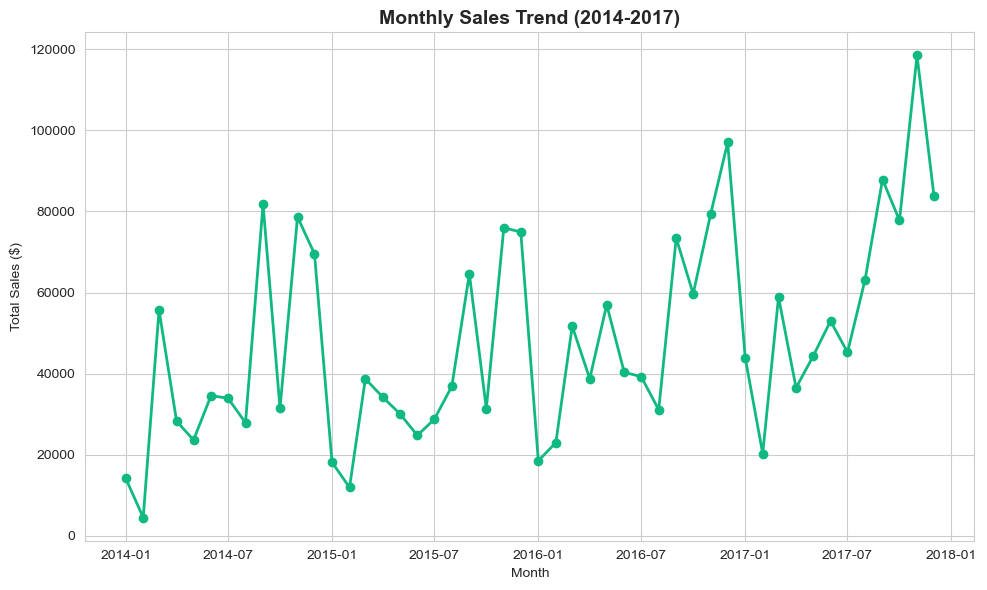

success


In [27]:
# chart
# monthly sales trend
# y-axis
monthly_sales = df.groupby(df["order_date"].dt.to_period("M"))["sales"].sum()
# fix the date format for plotting
# X-axis
monthly_sales.index = monthly_sales.index.to_timestamp() 
# new chart
plt.figure()
plt.plot(monthly_sales.index,monthly_sales.values,marker="o",color="#10b981",linewidth=2)
# labels
plt.title("Monthly Sales Trend (2014-2017)",fontsize=14,fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
# adjust space not to overlap
plt.tight_layout()
plt.show()
print("success")

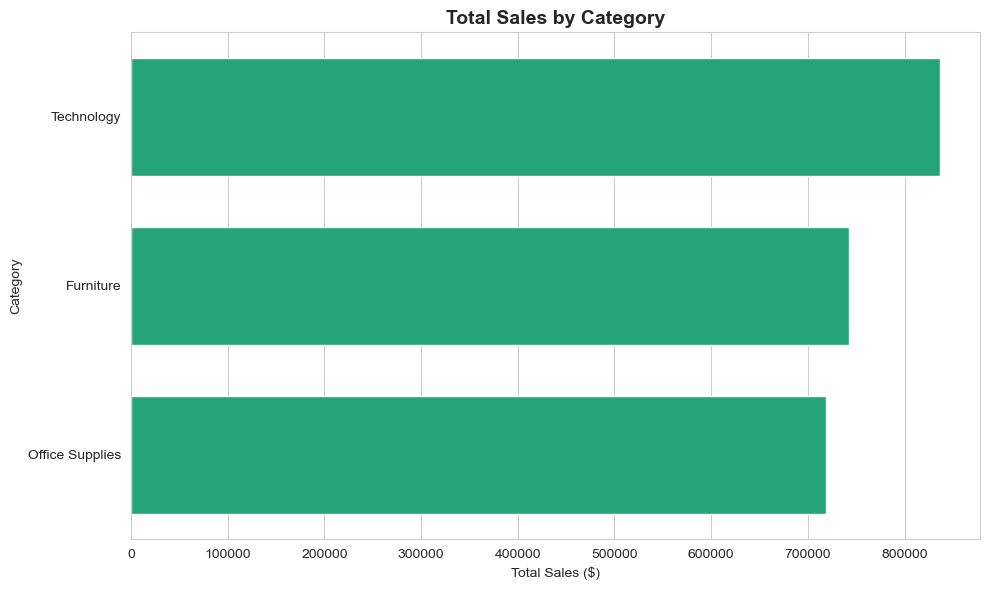

In [28]:
# sales by category 
category_sales = df.groupby("category")["sales"].sum().sort_values(ascending=False)
plt.figure()
sns.barplot(x=category_sales.values, y=category_sales.index,width=0.7,color="#10b981")
plt.title("Total Sales by Category", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

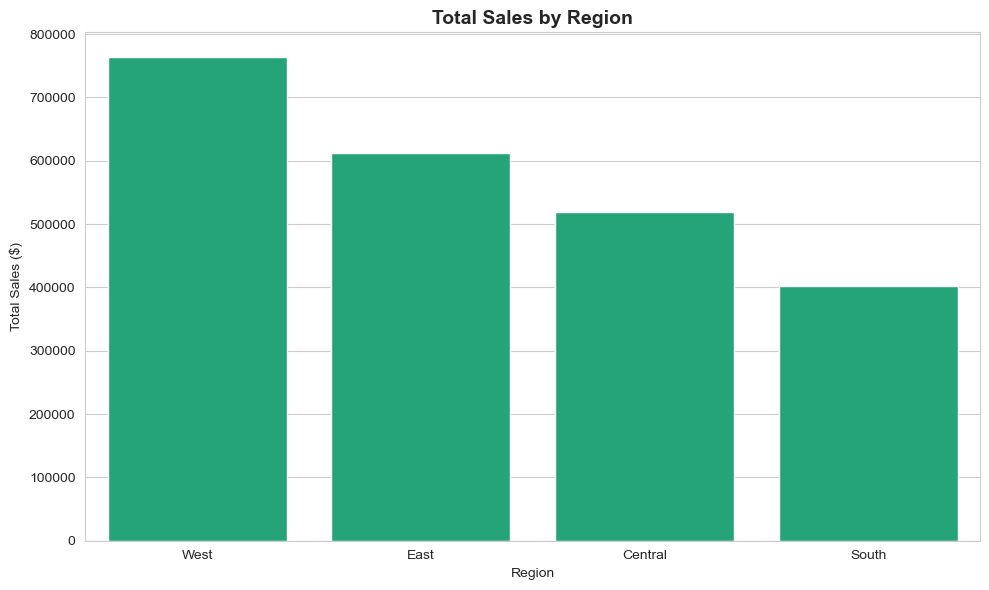

In [29]:
# sales by region
region_sales = df.groupby("region")["sales"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=region_sales.index, y=region_sales.values,color="#10b981")
plt.title("Total Sales by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

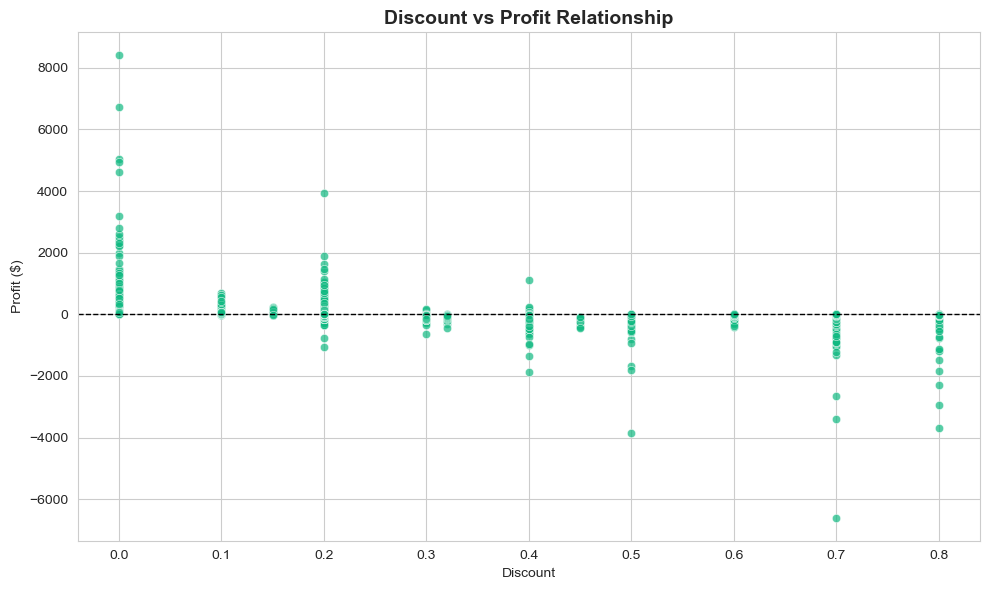

In [32]:
# scatter plot
# discount vs profit
plt.figure()
sns.scatterplot(data=df, x="discount", y="profit", alpha=0.7, color="#10b981")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Discount vs Profit Relationship", fontsize=14, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

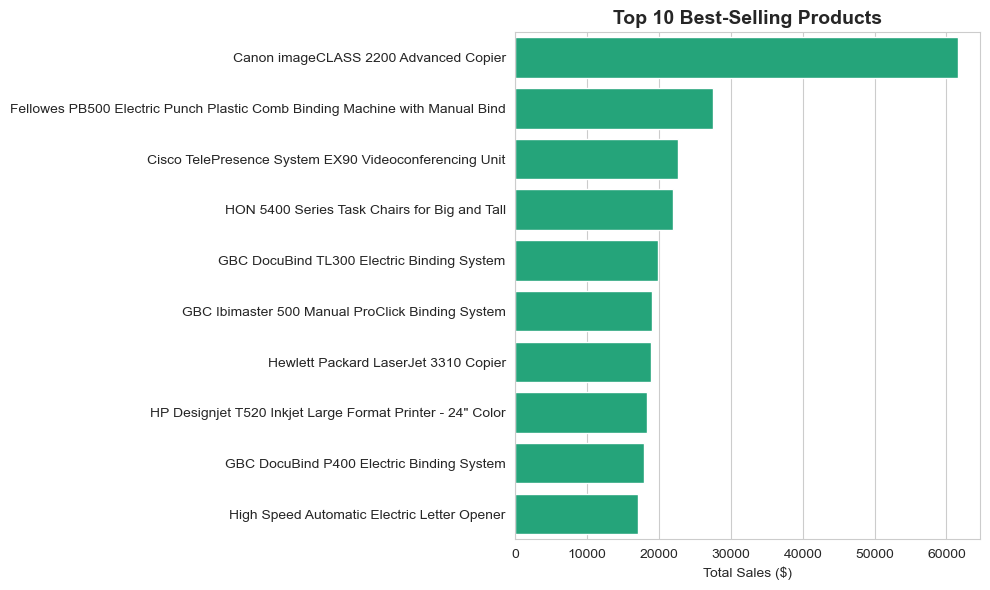

In [31]:
# top-10 best selling products
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=top_products.values, y=top_products.index,color="#10b981")
plt.title("Top 10 Best-Selling Products", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()

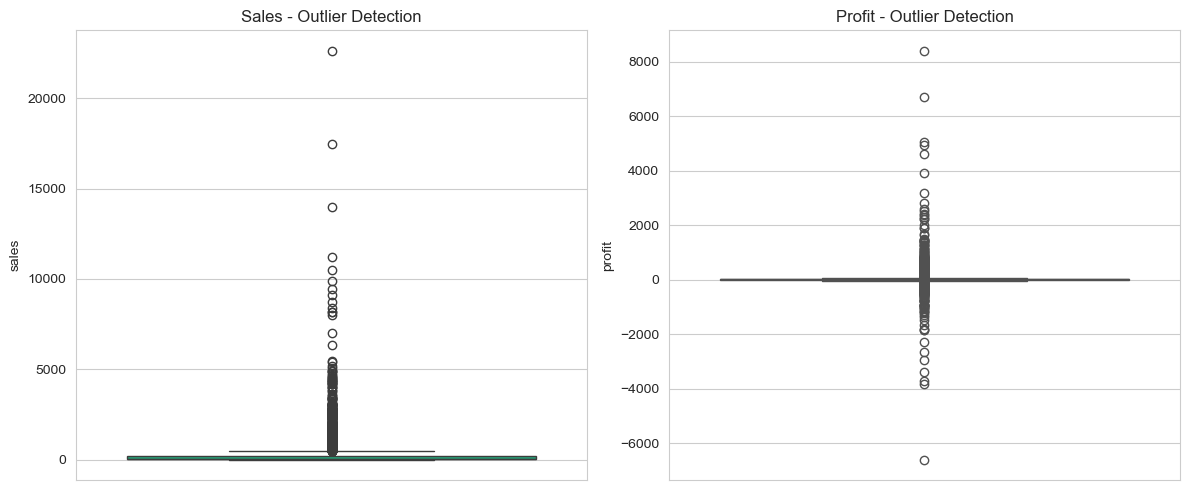

In [33]:
# chart outliers detection chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df["sales"], ax=axes[0], color="#10b981")
axes[0].set_title("Sales - Outlier Detection")
sns.boxplot(y=df["profit"], ax=axes[1], color="#f97316")
axes[1].set_title("Profit - Outlier Detection")
plt.tight_layout()
plt.show()